In [137]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

In [138]:
# generate a random unit vector
def random_unit_vector():
    vec = np.random.normal(size=3)
    return vec / np.linalg.norm(vec)

# project to xy plane
def project_to_2d(vec):
    projection_matrix = np.array([[1, 0, 0], [0, 1, 0]])
    return projection_matrix @ vec

# calculate angle between vectors
def angle_between_vectors(v1, v2):
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    a = np.arccos(np.clip(cos_theta, -1.0, 1.0)) * (180 / np.pi)  # Convert to degrees
    if a > 90:
        return 180 - a
    else:
        return a
    
# simulate a random sample of angles
def simulate_angle_dist(n):
    angles = []
    for _ in range(n):
        v1 = project_to_2d(random_unit_vector())
        v2 = project_to_2d(random_unit_vector())
        angle = angle_between_vectors(v1, v2)
        angles.append(angle)
    return angles

**Null Hypothesis**: The measured angles are randomly distributed

**Alternative Hypothesis**: The measured angles are not randomly distributed

Baseline comparison for two randomly generated angle distributions with n=27
Significance Proportion : 0.0527


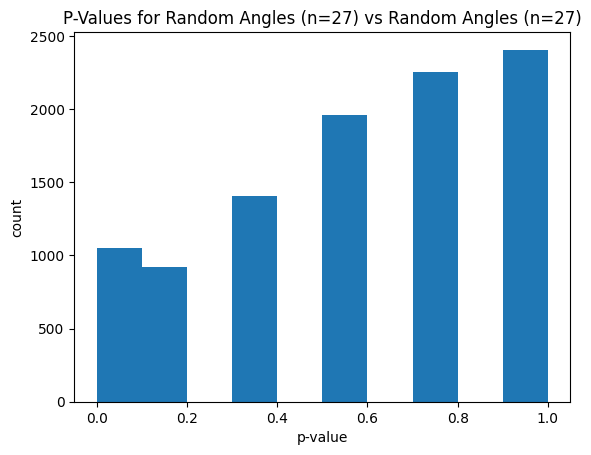

Comparison of 27 measured angles with a randomly generated angle distribution with n=27
Significance Proportion : 0.7183


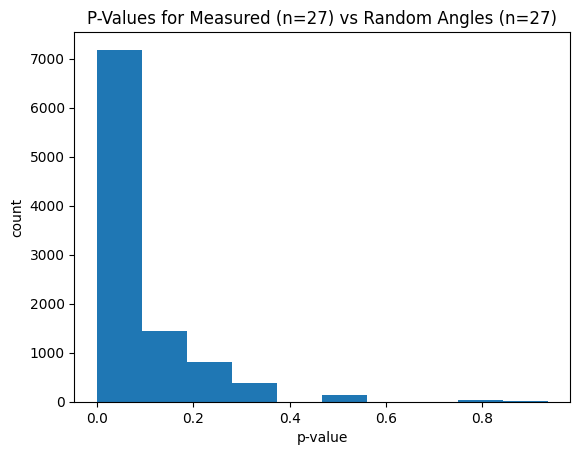

In [139]:
# load measured angles
angles = pd.read_csv('../results/angles.csv')
measured_angles = angles['smallest_angle'].to_numpy()

# baseline comparison for two randomly generated angle distributions with n=27
p_values = []
for i in range(10000):
    p_value = stats.ks_2samp(simulate_angle_dist(27), simulate_angle_dist(27)).pvalue
    p_values.append(p_value)
proportion = np.mean(np.array(p_values) < 0.05)
print("Baseline comparison for two randomly generated angle distributions with n=27")
print(f"Significance Proportion : {proportion}")
plt.hist(p_values)
plt.title("P-Values for Random Angles (n=27) vs Random Angles (n=27)")
plt.xlabel("p-value")
plt.ylabel("count")
plt.show()

# comparison of 27 measured angles with a randomly generated angle distribution with n=27
p_values = []
for i in range(10000):
    p_value = stats.ks_2samp(simulate_angle_dist(27), measured_angles).pvalue
    p_values.append(p_value)
proportion = np.mean(np.array(p_values) < 0.05)
print("Comparison of 27 measured angles with a randomly generated angle distribution with n=27")
print(f"Significance Proportion : {proportion}")
plt.hist(p_values)
plt.title("P-Values for Measured (n=27) vs Random Angles (n=27)")
plt.xlabel("p-value")
plt.ylabel("count")
plt.show()


The baseline Monte Carlo simulation demonstrates what we would expect if the measured angles were indeed random, which is a proportion of p-values below 0.05 of 5%. Since a majority of p-values (~70%) from the Monte Carlo simulation that compared our 27 measured angles with a random distribution of 27 angles with a Kolmogorov-Smirnov test were below 0.05, we can reasonably conclude that the measured angles are not randomly distributed; we reject the null hypothesis. However, the fact that 30% of Kolmogorov-Smirnov tests did not reject the null hypthesis indicates that the difference from a random distribution is not overwhelming. This could also be attributed to our low sample size of 27.